<a href="https://colab.research.google.com/github/x-senpai-x/Options-Pricing/blob/main/Black_Scholes_Merton_(3).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Black-Scholes-Merton (BSM) model
The Black-Scholes-Merton (BSM) model is a widely used mathematical framework for pricing European options. It assumes that asset prices follow a geometric Brownian motion (GBM), meaning prices change continuously with a constant drift and volatility. However, Merton extended the model by introducing a jump-diffusion process, allowing for sudden price changes, making the model more realistic for financial markets.

![image.png](attachment:9802640f-c805-4091-9c34-4aaee74cdc4f.png)

![image.png](attachment:750dd629-bb22-470b-b551-bb85ce9456fe.png)


## Explanation of Parameters
- C,P = Call and put option prices
- S0 = Cent stock price
- K = Strike price
- T = Time to expiration (in years)
- r = Risk-free interest rate (annualized, continuously compounded)
- q = Continuous dividend yield (if applicable)
- σ = Volatility of the stock (annualized)
- N(d) = Cumulative standard normal distribution function (probability that a standard normal variable is ≤ d)

## Assumptions of the BSM Model:

- No Arbitrage: The market is arbitrage-free.
- Lognormal Stock Prices with Jumps: The stock price follows a geometric Brownian motion, but with random jumps modeled by a Poisson process.
- Sudden Price Changes (Jumps): Prices can experience large, discrete jumps at random intervals.
- Constant Risk-Free Rate: The risk-free interest rate (r) remains fixed over time.
- Constant Volatility (Between Jumps): The asset follows a constant volatility process, but jumps create additional uncertainty.
- No Transaction Costs: Trading is frictionless.
- European Options Only: The option can only be exercised at expiration.
- Dividends Included: Merton extended the Black-Scholes model to handle continuous dividend yields (q).

![image.png](attachment:c5162cea-8dd7-499a-bf1a-db509c83fcdf.png)

## Applying BSM model on Nifty

In [ ]:
##Calculating the realised volatility of the stock
import numpy as np
from scipy.stats import norm # to generate the normal distribution
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime as dt , timedelta as td
end_date = dt.today().strftime('%Y-%m-%d')
start_date = (dt.today()-td(days=365)).strftime('%Y-%m-%d')
# Fetch historical data for Nifty 50 (symbol: ^NSEI)
nifty = yf.download("^NSEI",start_date,end_date)
nifty['daily_return'] = nifty['Adj Close'].pct_change()
nifty.dropna(inplace=True)
daily_volatility = nifty['daily_return'].std()
annual_volatility = daily_volatility*np.sqrt(252)
print(f"Annualized Historical Volatility (last 1 year): {annual_volatility * 100:.2f}%")

[*********************100%***********************]  1 of 1 completed

Annualized Historical Volatility (last 1 year): 13.95%


In [ ]:
class BSM:
    def __init__(self,S,K,T,r,q,sigma):
        self.S=float(S)
        self.K=float(K)
        self.T=float(T)
        self.r=float(r)
        self.q=float(q)
        self.sigma=float(sigma)
        self.d1=self._calculate_d1()
        self.d2=self._calculate_d2()

        #insert the functions
    def _calculate_d1(self):
        self.d1=(np.log(self.S/self.K)+(self.r-self.q+0.5*self.sigma**2)*self.T)/(self.sigma*np.sqrt(self.T))
        return self.d1
    def _calculate_d2(self):
        self.d2=self.d1-self.sigma*np.sqrt(self.T)
        return self.d2
    def call_price(self):
        self.call_price=self.S*np.exp(-self.q*self.T)*norm.cdf(self.d1)-self.K*np.exp(-self.r*self.T)*norm.cdf(self.d2)
        return self.call_price
    def put_price(self):
        self.put_price=self.K*np.exp(-self.r*self.T)*norm.cdf(-self.d2)-self.S*np.exp(-self.q*self.T)*norm.cdf(-self.d1)
        return self.put_price
    def call_delta(self):
        self.call_delta=np.exp(-self.q*self.T)*norm.cdf(self.d1)
        return self.call_delta
    def put_delta(self):
        self.put_delta=np.exp(-self.q*self.T)*norm.cdf(-self.d1)
        return self.put_delta
    def call_gamma(self):
        self.call_gamma=np.exp(-self.q*self.T)*norm.pdf(self.d1)/(self.S*self.sigma*np.sqrt(self.T))
        return self.call_gamma
    def put_gamma(self):
        return self.call_gamma()
    def call_vega(self):
        self.call_vega=0.01*self.S*np.exp(-self.q*self.T)*norm.pdf(self.d1)*np.sqrt(self.T)
        return self.call_vega
    def put_vega(self):
        return self.call_vega()
    def call_theta(self):
        self.call_theta=(-self.S*np.exp(-self.q*self.T)*norm.pdf(self.d1)*self.sigma/(2*np.sqrt(self.T))-self.r*self.K*np.exp(-self.r*self.T)*norm.cdf(self.d2)+self.S*self.q*np.exp(-self.q*self.T)*norm.cdf(self.d1))*0.004
        return self.call_theta
    def put_theta(self):
        self.put_theta=(-self.S*norm.pdf(self.d1)*self.sigma/(2*np.sqrt(self.T))+self.r*self.K*np.exp(-self.r*self.T)*norm.cdf(-self.d2)-self.S*self.q*np.exp(-self.q*self.T)*norm.cdf(-self.d1))*0.004
        return self.put_theta
    def call_rho(self):
        self.call_rho=0.01*self.K*self.T*np.exp(-self.r*self.T)*norm.cdf(self.d2)
        return self.call_rho
    def put_rho(self):
        self.put_rho=-0.01*self.K*self.T*np.exp(-self.r*self.T)*norm.cdf(-self.d2)
        return self.put_rho

### Testing on Nifty

In [ ]:

if __name__ == "__main__":
    S0 = 23275    # Current stock price
    K = 23700.00     # Strike price
    T = ((dt(2025,1,30)-dt(2025,1,7)).days+1)/365    #time in years
    r = 0.06857    # Risk-free rate (6.857%)
    sigma = annual_volatility # Volatility
    q=0.0124  #1 year avg div

    # Create Black-Scholes model instance
    bs = BSM(S0, K, T, r,q, sigma)

    # Calculate option prices
    call_price = bs.call_price()
    put_price = bs.put_price()
        # Print results
    print(f"Parameters:")
    print(f"Stock Price (S0): ${S0}")
    print(f"Strike Price (K): ${K}")
    print(f"Time to Expiration (T): {T} years")
    print(f"Risk-free Rate (r): {r*100}%")
    print(f"Volatility (σ): {sigma*100}%")
    print(f"\nOption Prices:")
    print(f"Call Option Price: ${call_price:.2f}")
    print(f"Put Option Price: ${put_price:.2f}")
    print(f"\nGreeks:")
    print(f"Call Delta: {bs.call_delta():.4f}")
    print(f"Put Delta: {-bs.put_delta():.4f}")
    print(f"Gamma: {bs.call_gamma():.4f}")

Parameters:
Stock Price (S0): $23275
Strike Price (K): $23700.0
Time to Expiration (T): 0.06575342465753424 years
Risk-free Rate (r): 6.857%
Volatility (σ): 13.947396135610807%

Option Prices:
Call Option Price: $192.26
Put Option Price: $529.61

Greeks:
Call Delta: 0.3499
Put Delta: -0.6493
Gamma: 0.0004


## Fetching Necessary Details from option chain

In [ ]:
import requests
import pandas as pd

# Fetch Nifty Option Chain Data
url = "https://www.nseindia.com/api/option-chain-indices?symbol=NIFTY"

# Headers to simulate a browser request
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/85.0.4183.121 Safari/537.36",
    "Accept-Language": "en-US,en;q=0.9",
    "Accept-Encoding": "gzip, deflate, br"
}

# Fetch data from NSE API
session = requests.Session()
response = session.get("https://www.nseindia.com", headers=headers)  # First visit to set cookies

response = session.get(url, headers=headers)
data = response.json() # Parse JSON data

"""
data is a dictionary with keys: 'records' and 'filtered'

records contains complete, unfiltered data from the Nifty Option Chain API.
Structure:
data: A list of all option chain entries (calls and puts) across various expiry dates and strike prices.
expiryDates: A list of all available expiry dates.
timestamp: The timestamp of when the data was fetched.
underlyingValue: The current price of the NIFTY index.

filtered contains a pre-filtered subset of the option chain data. It focuses on the nearest expiry date and relevant strike prices close to the current NIFTY value
Structure:
CE: Filtered Call Option data.
PE: Filtered Put Option data.
data: Limited to strikes near the current NIFTY index (e.g., ±10 strikes around the spot price).
"""

# User-defined expiry date
TARGET_EXPIRY = '27-Feb-2025'  # desired expiry date

# Parse data
options_data = []
for record in data['records']['data']: # record contains expiryDate, strikePrice, CE, PE
    expiry_date = record['expiryDate']
    if expiry_date == TARGET_EXPIRY:  # Filter by specific expiry date
        strike_price = record['strikePrice']
        ltp_call = record.get('CE', {}).get('lastPrice', None)  # Call Option LTP
        ltp_put = record.get('PE', {}).get('lastPrice', None)   # Put Option LTP
        iv_call = record.get('CE', {}).get('impliedVolatility', None)
        iv_put = record.get('PE', {}).get('impliedVolatility', None)
        options_data.append({
            'expiry_date': expiry_date,
            'strike': strike_price,
            'ltp_call': ltp_call,
            'ltp_put': ltp_put,
            'iv_call': iv_call,
            'iv_put': iv_put,
        })

# Convert to DataFrame
df = pd.DataFrame(options_data)
if df.empty:
    print(f"No data found for expiry date: {TARGET_EXPIRY}")
else:
    print(f"Data fetched successfully for expiry date: {TARGET_EXPIRY}")

print(df)


Data fetched successfully for expiry date: 27-Feb-2025
     expiry_date  strike  ltp_call  ltp_put  iv_call  iv_put
0    27-Feb-2025   21100      0.00    25.70     0.00   21.75
1    27-Feb-2025   21150      0.00    27.20     0.00   21.72
2    27-Feb-2025   21200      0.00    28.70     0.00   21.47
3    27-Feb-2025   21250      0.00    31.45     0.00   21.35
4    27-Feb-2025   21300      0.00    33.95     0.00   21.31
..           ...     ...       ...      ...      ...     ...
104  27-Feb-2025   26300      9.20  2850.00    20.45    0.00
105  27-Feb-2025   26350      0.00     0.00     0.00    0.00
106  27-Feb-2025   26400      9.00  3000.00    20.93    0.00
107  27-Feb-2025   26450      9.15     0.00    21.26    0.00
108  27-Feb-2025   26500      9.20  3131.00    21.50   20.61

[109 rows x 6 columns]


In [ ]:
S=data['records']['underlyingValue']    # Current stock price
r = 0.06857    # Risk-free rate (6.857%)
q=0.0124
sigma = annual_volatility # Volatility
expiry_date = dt.strptime(TARGET_EXPIRY, "%d-%b-%Y")
today = dt.today()
T = (expiry_date - today).days / 365 + 1 / 365
df = df[(df['strike'] >= 23450) & (df['strike'] <= 24800)]
df['bs_call_price'] = df['strike'].apply(lambda K: BSM(S, K, T, r,q, sigma).call_price())
df['bs_put_price'] = df['strike'].apply(lambda K: BSM(S, K, T, r,q, sigma).put_price())
df

,expiry_date,strike,ltp_call,ltp_put,iv_call,iv_put,bs_call_price,bs_put_price
47,27-Feb-2025,23450,409.05,517.00,17.07,18.25,276.502722,453.607115
48,27-Feb-2025,23500,384.20,534.30,17.51,18.21,256.430705,483.272780
49,27-Feb-2025,23550,355.65,567.85,17.42,18.06,237.411715,513.991472
50,27-Feb-2025,23600,335.15,595.00,17.39,17.70,219.426368,545.743808
51,27-Feb-2025,23650,311.40,615.10,17.53,17.87,202.452623,578.507745
52,27-Feb-2025,23700,294.00,641.05,17.26,17.80,186.465983,612.258787
53,27-Feb-2025,23750,272.00,677.30,17.22,17.75,171.439718,646.970204
54,27-Feb-2025,23800,255.40,699.45,17.07,17.63,157.345097,682.613266
55,27-Feb-2025,23850,234.35,734.40,17.18,17.59,144.151632,719.157483
56,27-Feb-2025,23900,219.75,774.95,16.90,17.49,131.827320,756.570854


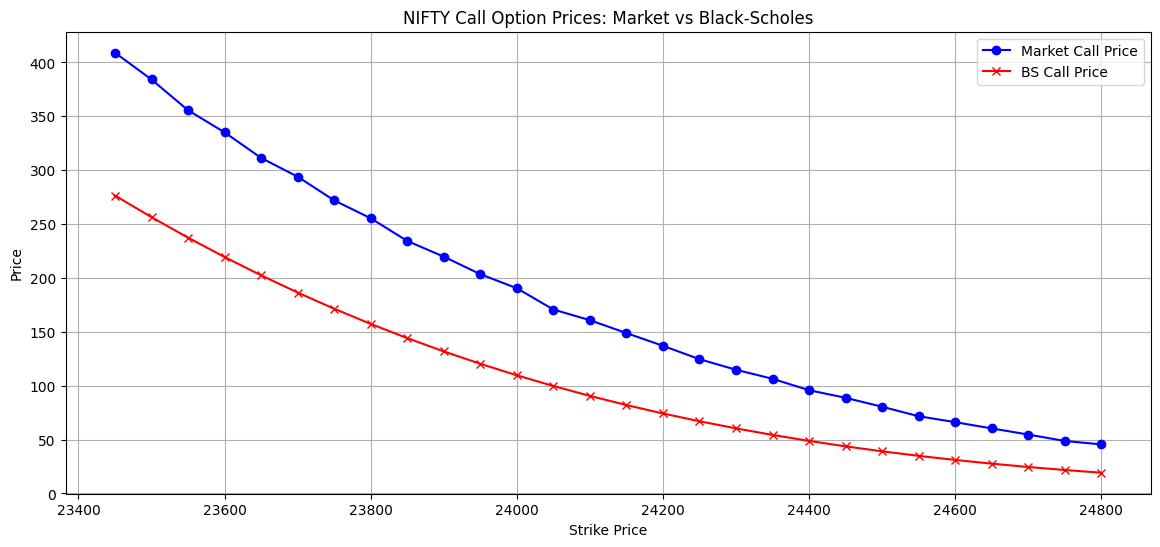

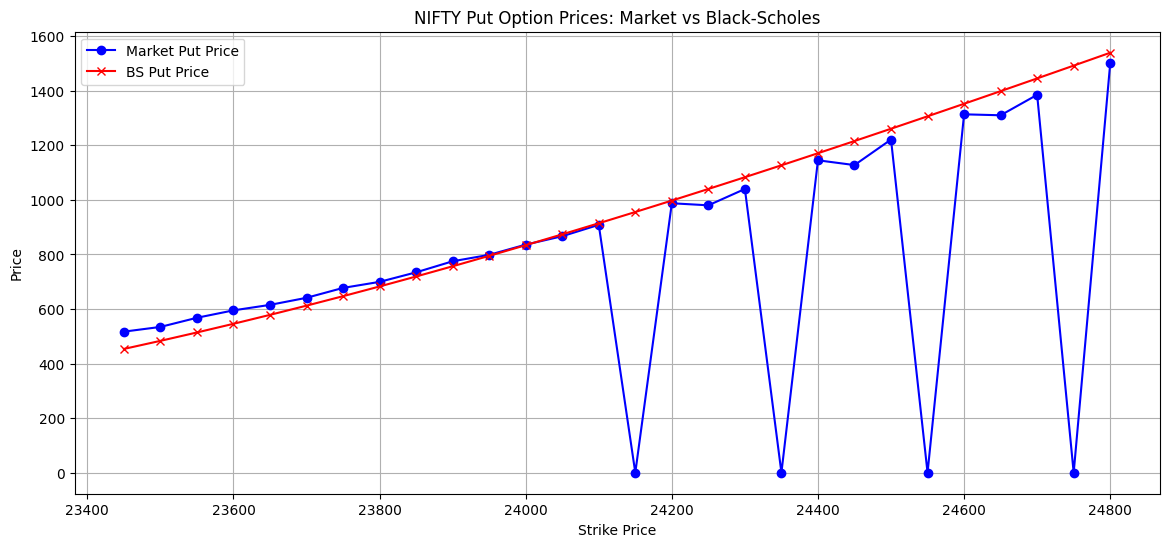

In [ ]:
import matplotlib.pyplot as plt

# Plot Call Prices
plt.figure(figsize=(14, 6))
plt.plot(df['strike'], df['ltp_call'], 'o-', label='Market Call Price', color='b')
plt.plot(df['strike'], df['bs_call_price'], 'x-', label='BS Call Price', color='r')
plt.title('NIFTY Call Option Prices: Market vs Black-Scholes')
plt.xlabel('Strike Price')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

# Plot Put Prices
plt.figure(figsize=(14, 6))
plt.plot(df['strike'], df['ltp_put'], 'o-', label='Market Put Price', color='b')
plt.plot(df['strike'], df['bs_put_price'], 'x-', label='BS Put Price', color='r')
plt.title('NIFTY Put Option Prices: Market vs Black-Scholes')
plt.xlabel('Strike Price')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()
